In [22]:
### SIP Inference Pipeline

### Required Packages
import h5py,hdf5plugin,numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from salt.modelwrapper import ModelWrapper
import scipy.stats as stats
import yaml
from matplotlib.lines import Line2D
import warnings
 
### importing functions
%run ./SIP_inference_functions_test.ipynb
%run ./SIP_analysis_functions_test.ipynb

### removing warnings 
warnings.filterwarnings("ignore", message="invalid value encountered in scalar divide")  
warnings.filterwarnings("ignore", message="Cannot use flash-varlen backend. No GPU available. Reverting to torch-math.") 

In [23]:
### pipeline input
CONFIG = "SIP_truth_GN2_config.yaml" # Text file for configuring h5 test dataset

### pipeline configs
analysis_mode = True # plots graphs and histograms, make false and turn on save_mode to just save the model
save_mode = True # saves output jet flavour probabilities, pt, eta and truth flavours for comparison to another model

In [24]:
### Running Inference
if analysis_mode:
    test_file, sample_size, stored, low_pt_cutoff, high_pt_cutoff, model_dict, plot_dict = config_parser(CONFIG, analysis_mode)
else:
    test_file, sample_size, stored, low_pt_cutoff, high_pt_cutoff, model_dict = config_parser(CONFIG, analysis_mode)

print(f'Config file: {CONFIG} Parsed')
for model_name,model in model_dict.items():
    print("")
    print(f'Running Inference On Model: {model_name}')
    data_dict,pad_dict,comp_probs,truth_flavours,pt_vals,eta_vals = h5_test_datafile_prepper(test_file,model["inference_variables"]
                                                                                             ,sample_size,stored,low_pt_cutoff,high_pt_cutoff)
    model["data_dict"] = data_dict
    model["pad_dict"] = pad_dict
    model["comp_probs"] = comp_probs
    model["truth_flavour"] = truth_flavours
    model["pt_vals"] = pt_vals
    model["eta_vals"] = eta_vals
    
    print(f'Test File: {test_file} Prepared')
    ckpt, norm = model["model_checkpoint"], model["norm_dict"]
    loaded_model = model_loader(ckpt, norm)
    print(f'Checkpoint Model: {model["model_checkpoint"]} Loaded')
    
    probs,scores = inference_run(data_dict,pad_dict,loaded_model,model)
    print(f'Inference Run')
    
    model["probs"] = probs
    model["scores"] = scores
    del model["pad_dict"]["REGISTERS"]

    if model["inference_output"] == "scores":
        model = scores_unnormaliser(model)
    
    if save_mode:
        save_output(probs,pt_vals,eta_vals,truth_flavours,model_name,ckpt,test_file,CONFIG,sample_size)
        print(f'Data saved as: {model_name}_inference_output.csv\nMetadata saved as: {model_name}_inference_run_data.txt')

print("")
print(f'Inference Complete ')

Config file: SIP_truth_GN2_config.yaml Parsed

Running Inference On Model: truth_classification_model
Test File: truth_regression_model/pp_output_test_ttbar.h5 Prepared
Checkpoint Model: ckpts/epoch=013-val_loss=0.62472.ckpt Loaded
Inference Run
Data saved as: truth_classification_model_inference_output.csv
Metadata saved as: truth_classification_model_inference_run_data.txt

Running Inference On Model: truth_regression_model
Test File: truth_regression_model/pp_output_test_ttbar.h5 Prepared
Checkpoint Model: ckpts/truth_regression_epoch=018-val_loss=0.51368.ckpt Loaded
Inference Run
Data saved as: truth_regression_model_inference_output.csv
Metadata saved as: truth_regression_model_inference_run_data.txt

Running Inference On Model: GN2_model
Test File: truth_regression_model/pp_output_test_ttbar.h5 Prepared
Checkpoint Model: ckpts/GN2_model_epoch=010-val_loss=0.59503.ckpt Loaded
Inference Run
Data saved as: GN2_model_inference_output.csv
Metadata saved as: GN2_model_inference_run_dat

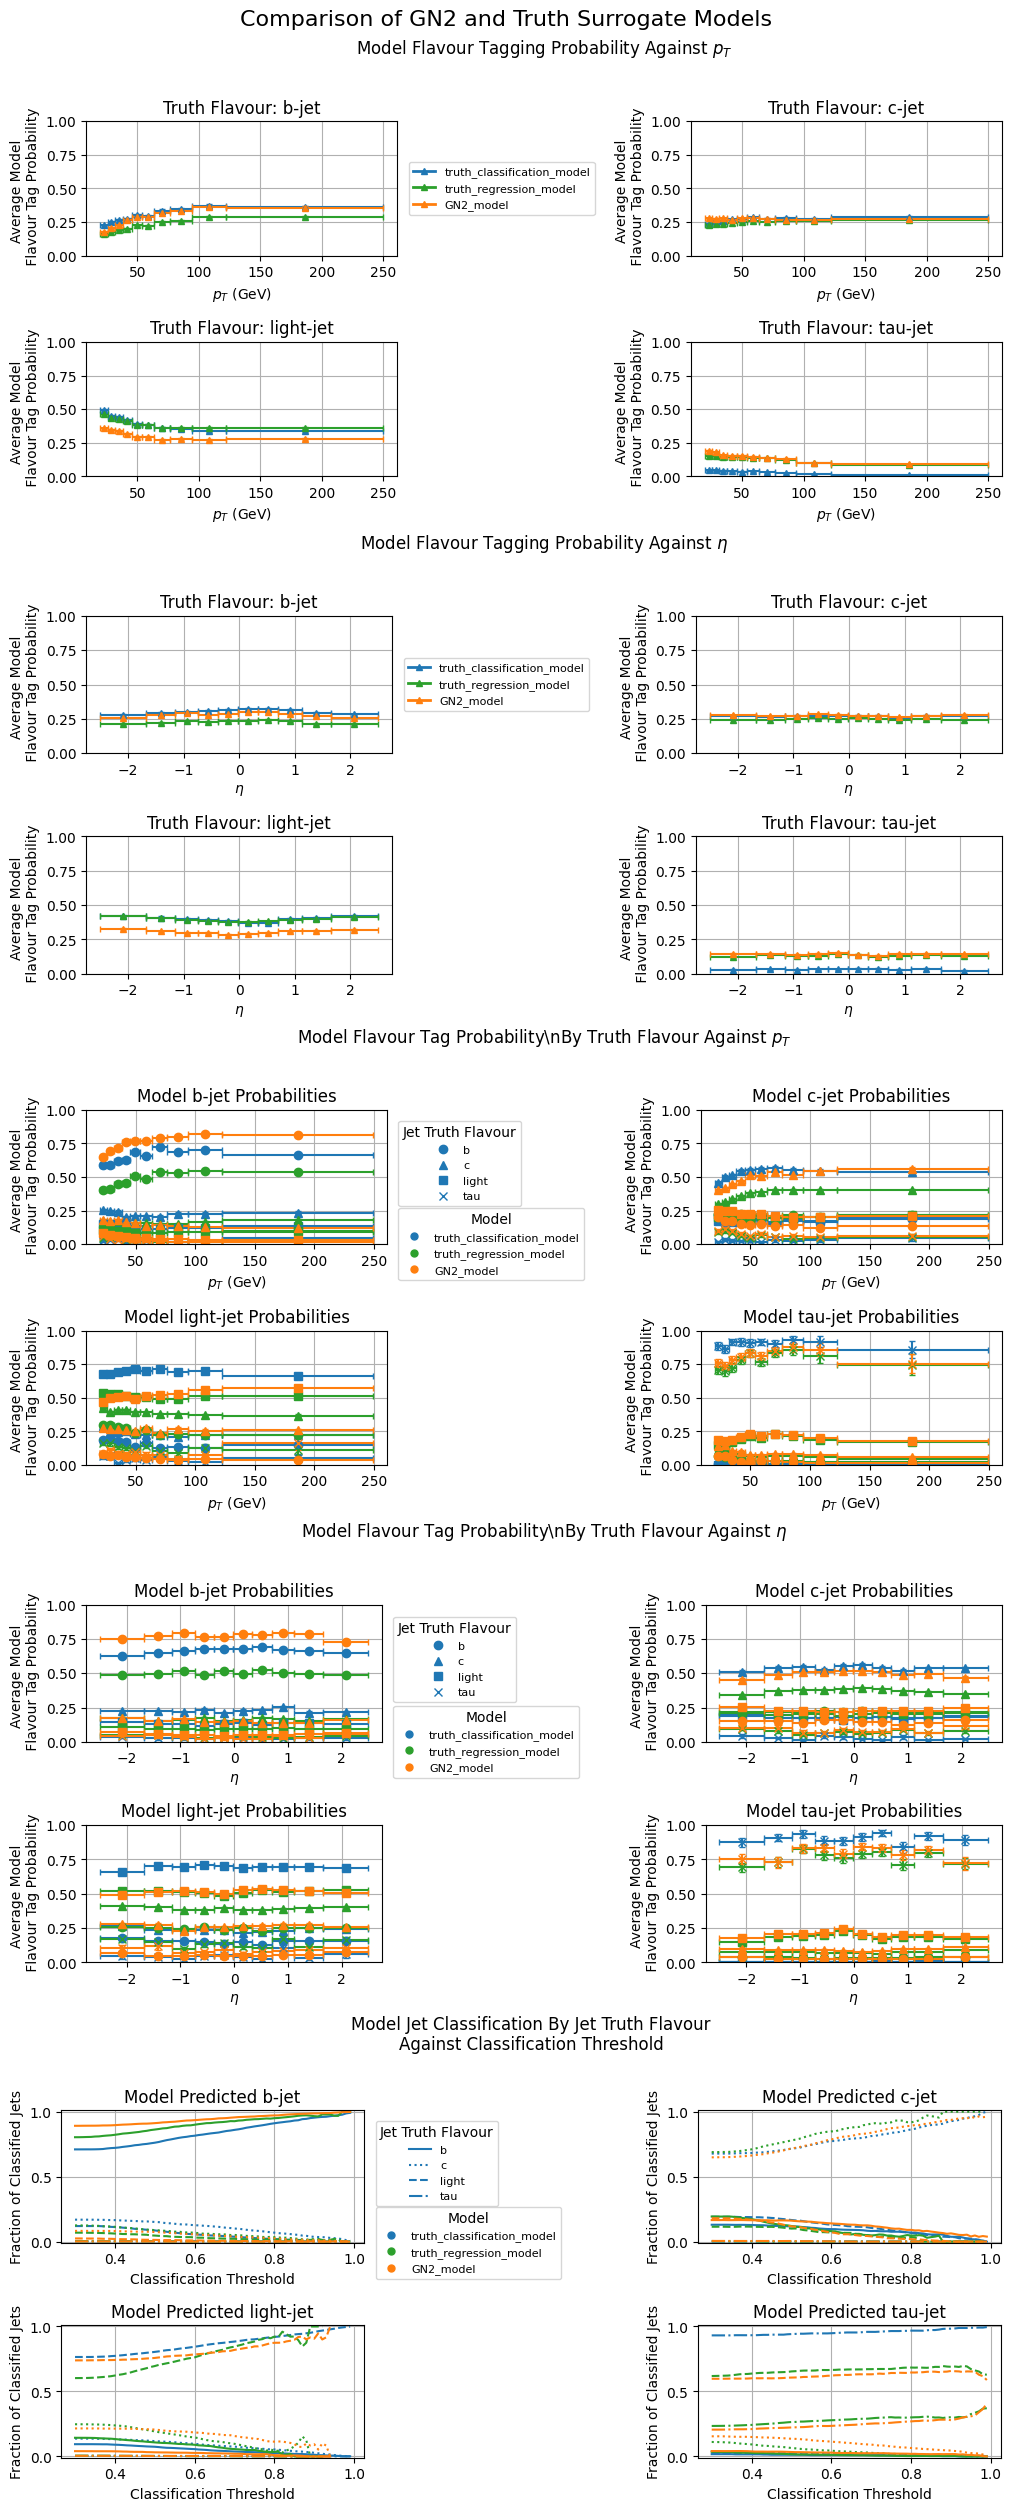

In [25]:
if analysis_mode:
    n_plots = len(plot_dict["plots"])
    fig = plt.figure(figsize=(10,5*n_plots), constrained_layout=True)
    gs = fig.add_gridspec(5,1)
    for model_name,model in model_dict.items():
        model["counts_dict"],model["confidences"] = jet_class_confidence_counter(model["probs"],model["truth_flavour"],0.3,0.01)
    i = 0
    for plot in plot_dict["plots"].values():
        if plot["plot_type"] == "profile_histogram":
            profile_histogram(fig,gs[i,0],model_dict,plot["x_data"],"probability",10)
        elif plot["plot_type"] == "profile_histogram_truth":
            profile_histogram_truth(fig,gs[i,0],model_dict,plot["x_data"],"probability",10)
        elif plot["plot_type"] == "prediction_plot":
            prediction_plot(fig,gs[i,0],model_dict)
        i += 1
    fig.suptitle(plot_dict["report_title"],fontsize=16)
    fig.savefig(f'{model_name}_inference_report.pdf',format="pdf")
    plt.show()